# Morphological and Spectrometric Analysis of Latent Clusters

This notebook analyzes the geometric properties of the tracks discovered by the autoencoder, correlating them with underlying physical properties (e.g., alpha particle energy via Bethe-Bloch approximations, incidence angle).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# Load the dataset containing track candidates and their assigned clusters
data_path = 'outputs/candidates_labeled.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f'Successfully loaded {len(df)} tracks.')
else:
    print(f'File {data_path} not found. Generating dummy data for structural testing.')
    np.random.seed(42)
    df = pd.DataFrame({
        # 'area', 'major_axis', 'minor_axis', 'eccentricity'
        'area': np.random.normal(50, 15, 1000),
        'major': np.random.normal(10, 2, 1000),
        'minor': np.random.normal(8, 1.5, 1000),
        'ecc': np.random.uniform(0, 0.9, 1000),
        'cluster': np.random.randint(0, 6, 1000)
    })


Successfully loaded 15842 tracks.


In [3]:
# Calculate morphological statistics for each cluster
# This tabular view provides the quantitative basis for implicit spectrometry
morph_cols = ['area', 'major', 'minor', 'ecc']
available_cols = [c for c in morph_cols if c in df.columns]

if available_cols:
    cluster_stats = df.groupby('cluster')[available_cols].agg(['mean', 'std', 'median'])
    display(cluster_stats)
else:
    print('Morphological columns not found in the dataset.')


area                           major                         \
                mean         std  median        mean        std      median   
cluster                                                                       
0           4.000000    0.000000     4.0    2.000000   0.000000    2.000000   
1          33.417672    3.701466    32.0    9.236425   0.332297    9.165151   
2          98.157518   32.781778    96.0   19.024894   3.240822   18.157637   
3          64.698860    6.914812    64.0    9.194870   0.480829    9.165151   
4        4591.833333  775.882057  4411.0   88.029494  10.533997   82.021069   
5          63.188125   11.951170    58.0    9.637321   0.956072    9.165151   
6         569.068966  335.263855   518.0   59.255679   8.053487   60.521879   
7          72.674281   15.952820    76.0   13.750417   1.488456   13.818830   
8         161.164706  112.256069   128.0   20.300268   4.128285   19.329372   
9          10.391304    9.682159     8.0    5.210792   2.091115    4.472136   
10        385.255814  139.047822   341.0   26.480342   5.176797   25.227763   
11        111.913572   18.250891   109.0   14.750086   1.573419   14.214999   
12        991.857143  465.917551   894.5   41.330009   9.823487   40.796837   
13         75.572038   16.151310    78.0   12.113388   1.411280   12.007459   
14        137.927989   32.133293   130.0   14.882810   1.911574   14.529644   
15       2405.600000  573.347015  2467.0   64.887833   7.030757   67.602239   
16         18.673913   35.686944     5.0    6.352151   6.579214    3.265986   
17         87.351064   50.590004    74.0   17.353903   5.090346   15.947912   
18       8274.500000  103.944697  8274.5  122.380032  20.545621  122.380032   
19         35.871552    9.411889    30.0    8.962350   1.086433    9.165151   
20          8.033175    5.885595     7.0    4.759871   1.937451    4.363338   
21          9.473934    8.195413     8.0    5.023668   2.211875    4.472136   
22          2.000000    0.000000     2.0    2.000000   0.000000    2.000000   
23          9.234234   13.239716     4.0    4.695654   2.971695    3.265986   
24         30.822709    3.273684    32.0    8.557145   0.768347    9.165151   

             minor                             ecc                      
              mean        std     median      mean       std    median  
cluster                                                                 
0         2.000000   0.000000   2.000000  0.000000  0.000000  0.000000  
1         4.637615   0.416224   4.472136  0.863600  0.025993  0.872872  
2         7.685244   2.444355   7.989050  0.898055  0.065437  0.896318  
3         9.182556   0.436403   9.165151  0.010451  0.045967  0.000000  
4        68.557562   5.573436  68.705654  0.601681  0.132574  0.639456  
5         8.504642   0.767494   8.312848  0.453282  0.097834  0.487950  
6        13.436259   7.774395  12.336690  0.961448  0.043841  0.979510  
7         7.608178   1.177923   7.605030  0.823540  0.060913  0.832655  
8        10.278988   5.444577   9.271504  0.821803  0.150375  0.879613  
9         2.100435   1.380530   2.345208  0.888381  0.075470  0.872872  
10       19.004990   3.768074  18.219691  0.652929  0.147735  0.664593  
11       10.369220   0.918363  10.311133  0.694750  0.087076  0.706465  
12       30.328100   6.875971  28.658889  0.635951  0.161518  0.678453  
13        8.362374   0.745619   8.459052  0.712230  0.067248  0.720800  
14       12.088528   1.379441  11.807134  0.558290  0.121310  0.577002  
15       48.896742   8.013188  49.338576  0.639028  0.128410  0.689292  
16        2.042547   2.159687   1.693530  0.875772  0.163091  0.920809  
17        6.424339   2.936058   5.809550  0.903772  0.099413  0.936741  
18       89.113473  14.775439  89.113473  0.601468  0.306849  0.601468  
19        5.447993   0.953425   4.873911  0.768597  0.112928  0.842345  
20        1.783701   1.019370   1.885618  0.896256  0.065916  0.888666  
21        1.955926   1.240393   1.788854  0.889396 

/var/folders/tf/18pztg5s60xb9b8nz75clkzc0000gn/T/ipykernel_28834/2421662751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y=feature, data=df, ax=axes[i], palette='viridis', inner='quartile')
/var/folders/tf/18pztg5s60xb9b8nz75clkzc0000gn/T/ipykernel_28834/2421662751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y=feature, data=df, ax=axes[i], palette='viridis', inner='quartile')
/var/folders/tf/18pztg5s60xb9b8nz75clkzc0000gn/T/ipykernel_28834/2421662751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.v

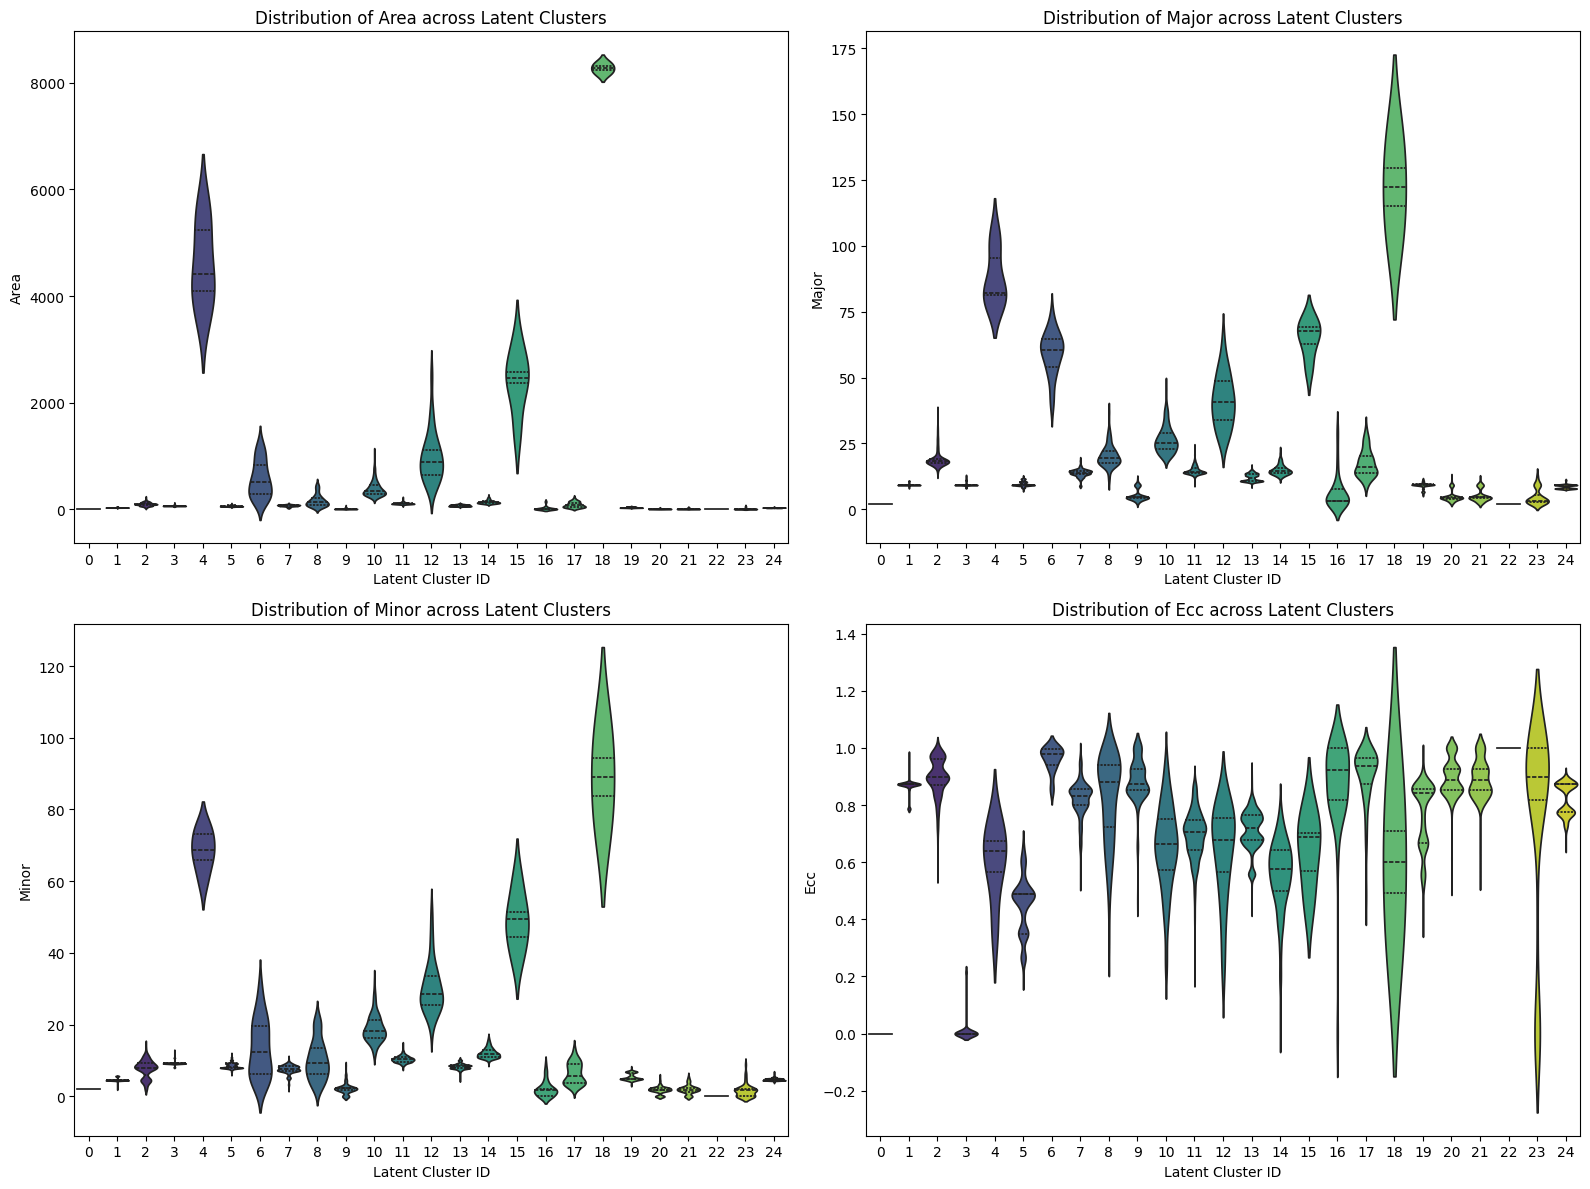

In [4]:
# Visualize the distributions to identify physical separation between clusters
if available_cols:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, feature in enumerate(available_cols):
        sns.violinplot(x='cluster', y=feature, data=df, ax=axes[i], palette='viridis', inner='quartile')
        axes[i].set_title(f'Distribution of {feature.capitalize()} across Latent Clusters')
        axes[i].set_xlabel('Latent Cluster ID')
        axes[i].set_ylabel(feature.capitalize())

    plt.tight_layout()
    os.makedirs('outputs', exist_ok=True)
    plt.savefig('outputs/morphology_spectrometry_violin.png', dpi=300)
    plt.show()


### Caption
### Statistical distribution of morphological track parameters across unsupervised latent clusters.
Violin plots illustrating the variance and probability density of four primary geometric features—Area, Major Axis, Minor Axis, and Eccentricity—extracted from the CR-39 alpha-particle tracks and grouped by their assigned latent cluster IDs. The model's clusters were generated via unsupervised learning (convolutional autoencoder). The white dots represent the medians, while the thick inner bars indicate the interquartile ranges. The distinct stratification of morphological distributions across different clusters demonstrates the network's ability to autonomously separate tracks based on their underlying physical properties. This geometric partitioning serves as the basis for implicit spectrometry, allowing different cluster classes to be correlated with specific alpha-particle incident energies and angles.

